In [ ]:
#===============================
#-GROUP PROJECT- TEAM 3- FILE UPLOAD
#=============================
from google.colab import files
uploaded = files.upload()

Saving netflix_customer_churn.csv to netflix_customer_churn.csv


## **CLEANING DATA**

In [ ]:
import pandas as pd
# Load the dataset
df = pd.read_csv(
    "netflix_customer_churn.csv",
    engine='python',
    encoding="utf-8",
    on_bad_lines="skip"
    )

df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [ ]:
df.shape

(5000, 14)

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [ ]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [ ]:
df.isna().sum()

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(5000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

Data Quality:

- 5000 customers, 14 variables

- No missing values

- No duplicate records

- Clean behavioral dataset


GDPR & Ethics:

- No sensitive personal data

- No ethnicity, religion, health, political data

- Only behavioral and subscription data used

- Model used for retention optimization

- No automated discrimination

# **ANALYTICAL CRM- SEGMENTATION**

In [ ]:
# SEGMENTATION DATA (Behavioral RFM)
# R = last_login_days
# F = watch_hours / avg_watch_time_per_day
# M = monthly_fee

seg_df = df[[
    "last_login_days",
    "watch_hours",
    "avg_watch_time_per_day",
    "monthly_fee",
    "number_of_profiles"
]].copy()

seg_df.head()

,last_login_days,watch_hours,avg_watch_time_per_day,monthly_fee,number_of_profiles
0,29,14.73,0.49,8.99,1
1,19,0.70,0.03,13.99,5
2,10,16.32,1.48,13.99,2
3,12,4.51,0.35,17.99,2
4,13,1.89,0.13,13.99,2


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(seg_df)

X[:5]

array([[-0.06215238,  0.25642504, -0.14689477, -1.27134085, -1.42996464],
       [-0.63246235, -0.91143244, -0.32249662,  0.08305133,  1.39549404],
       [-1.14574131,  0.38877668,  0.23103096,  0.08305133, -0.72359997],
       [-1.03167932, -0.59428796, -0.20033881,  1.16656507, -0.72359997],
       [-0.97464832, -0.81237682, -0.28432231,  0.08305133, -0.72359997]])

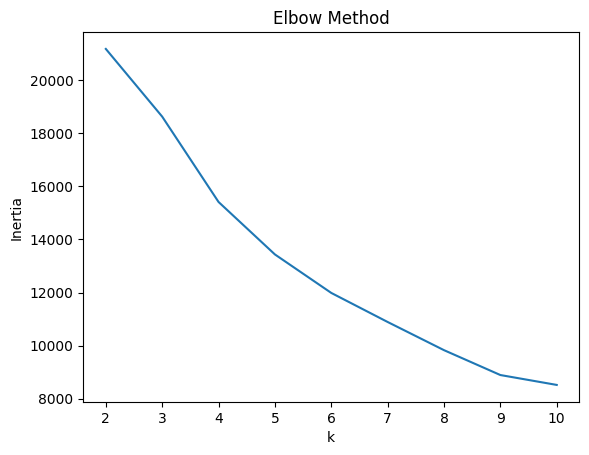

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
k = 6

km = KMeans(n_clusters=k, random_state=42)
df["segment"] = km.fit_predict(X)

df[["customer_id", "segment"]].head()

,customer_id,segment
0,a9b75100-82a8-427a-a208-72f24052884a,1
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,2
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,1
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,2
4,4e265c34-103a-4dbb-9553-76c9aa47e946,1


In [ ]:
# Mean profile by segment
seg_profile = df.groupby("segment")[[
    "last_login_days",
    "watch_hours",
    "avg_watch_time_per_day",
    "monthly_fee",
    "number_of_profiles",
    "churned"
]].mean().round(2)

# Segment size
seg_size = df["segment"].value_counts().sort_index()

seg_profile

,last_login_days,watch_hours,avg_watch_time_per_day,monthly_fee,number_of_profiles,churned
segment,,,,,,
0,30.46,8.54,0.51,8.99,3.44,0.66
1,29.24,9.24,0.56,14.20,1.30,0.62
2,15.34,7.71,0.85,16.21,3.92,0.21
3,0.85,27.60,17.36,14.08,2.94,0.00
4,30.09,40.41,2.01,13.63,3.27,0.01
5,47.31,9.52,0.20,16.18,3.73,0.69


In [81]:
seg_churn = df.groupby("segment")["churned"].mean().round(3)
seg_churn

,churned
segment,
0,0.664
1,0.616
2,0.214
3,0.000
4,0.007
5,0.688


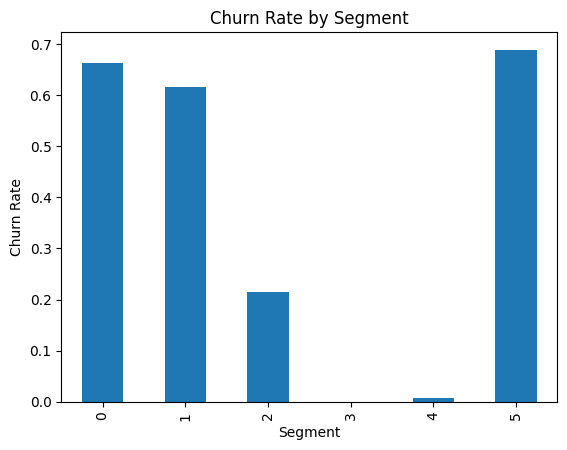

In [77]:
import matplotlib.pyplot as plt

churn_by_segment = df.groupby("segment")["churned"].mean()

plt.figure()
churn_by_segment.plot(kind="bar")
plt.title("Churn Rate by Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate")
plt.show()

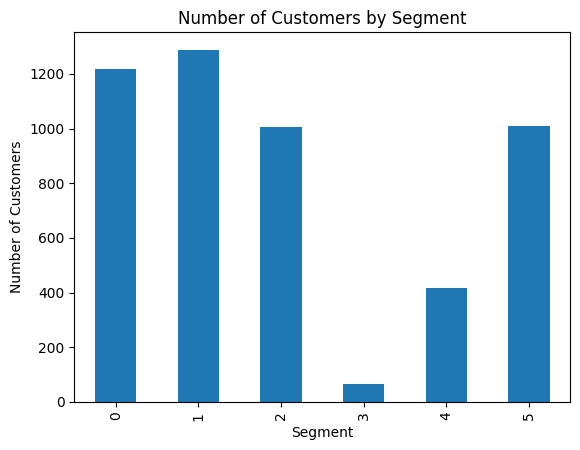

In [78]:
plt.figure()
df["segment"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Customers by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

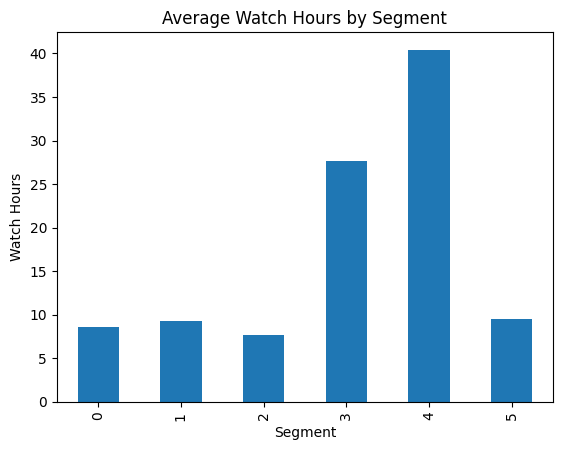

In [80]:
watch_by_segment = df.groupby("segment")["watch_hours"].mean()

plt.figure()
watch_by_segment.plot(kind="bar")
plt.title("Average Watch Hours by Segment")
plt.xlabel("Segment")
plt.ylabel("Watch Hours")
plt.show()

In [82]:
summary = seg_profile.copy()
summary["customers"] = seg_size
summary["churn_rate"] = seg_churn

summary = summary[[
    "customers",
    "churn_rate",
    "last_login_days",
    "watch_hours",
    "avg_watch_time_per_day",
    "monthly_fee",
    "number_of_profiles"
]]

summary

,customers,churn_rate,last_login_days,watch_hours,avg_watch_time_per_day,monthly_fee,number_of_profiles
segment,,,,,,,
0,1219,0.664,30.46,8.54,0.51,8.99,3.44
1,1288,0.616,29.24,9.24,0.56,14.20,1.30
2,1004,0.214,15.34,7.71,0.85,16.21,3.92
3,65,0.000,0.85,27.60,17.36,14.08,2.94
4,416,0.007,30.09,40.41,2.01,13.63,3.27
5,1008,0.688,47.31,9.52,0.20,16.18,3.73


In [98]:
summary["retention_rate"] = 1 - summary["churn_rate"]
summary

,customers,churn_rate,last_login_days,watch_hours,avg_watch_time_per_day,monthly_fee,number_of_profiles,retention_rate
segment,,,,,,,,
0,1219,0.664,30.46,8.54,0.51,8.99,3.44,0.336
1,1288,0.616,29.24,9.24,0.56,14.20,1.30,0.384
2,1004,0.214,15.34,7.71,0.85,16.21,3.92,0.786
3,65,0.000,0.85,27.60,17.36,14.08,2.94,1.000
4,416,0.007,30.09,40.41,2.01,13.63,3.27,0.993
5,1008,0.688,47.31,9.52,0.20,16.18,3.73,0.312


In [99]:
summary["clv_proxy"] = summary["monthly_fee"] * 12 * summary["retention_rate"]
summary

,customers,churn_rate,last_login_days,watch_hours,avg_watch_time_per_day,monthly_fee,number_of_profiles,retention_rate,clv_proxy
segment,,,,,,,,,
0,1219,0.664,30.46,8.54,0.51,8.99,3.44,0.336,36.24768
1,1288,0.616,29.24,9.24,0.56,14.20,1.30,0.384,65.43360
2,1004,0.214,15.34,7.71,0.85,16.21,3.92,0.786,152.89272
3,65,0.000,0.85,27.60,17.36,14.08,2.94,1.000,168.96000
4,416,0.007,30.09,40.41,2.01,13.63,3.27,0.993,162.41508
5,1008,0.688,47.31,9.52,0.20,16.18,3.73,0.312,60.57792


**Segment has:**

High churn + High fee
→ Big risk

High retention + High fees
→ Loyal value segment

Low fee + High churn
→ Low priority

In [100]:
segment_names = {
    0: "High Risk Basic",
    1: "High Risk Standard",
    2: "Stable Paying",
    3: "Top Loyal",
    4: "Heavy Streamers",
    5: "Inactive High Risk"
}

df["segment_name"] = df["segment"].map(segment_names)
df[["segment", "segment_name"]].drop_duplicates().sort_values("segment")

,segment,segment_name
6,0,High Risk Basic
0,1,High Risk Standard
1,2,Stable Paying
191,3,Top Loyal
15,4,Heavy Streamers
10,5,Inactive High Risk


**Segment Persona Summary**

Segment 0 – High Risk Basic

- High churn 66%

- Low fee, low engagement

- Price sensitive

- Low-cost retention needed

Segment 1 – High Risk Standard

- High churn 61%

- Medium fee users

- Core users at risk

- Personalized reactivation

Segment 2 – Stable Paying

- Churn 21%

- High retention

- Strong economic value

- Cross-sell opportunity

Segment 3 – Top Loyal

- Churn 0%

- Highest engagement

- Highest CLV

- VIP loyalty focus

Segment 4 – Heavy Streamers

- Very high usage

- Strong retention

- Upsell potential

Segment 5 – Inactive High Risk

- Highest churn 68%

- Long inactivity

- Immediate win-back campaign

# **Emotional CRM – Engagement analysis**

In [119]:
# Divide engagement to watch_hours
df["engagement_level"] = pd.cut(
    df["watch_hours"],
    bins=2,
    labels=["Low", "High"]
)

df.groupby("engagement_level")["churned"].mean()

/tmp/ipython-input-951/1492708070.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("engagement_level")["churned"].mean()


,churned
engagement_level,
Low,0.507876
High,0.000000


/tmp/ipython-input-951/1827944378.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_engagement = df.groupby("engagement_level")["churned"].mean()


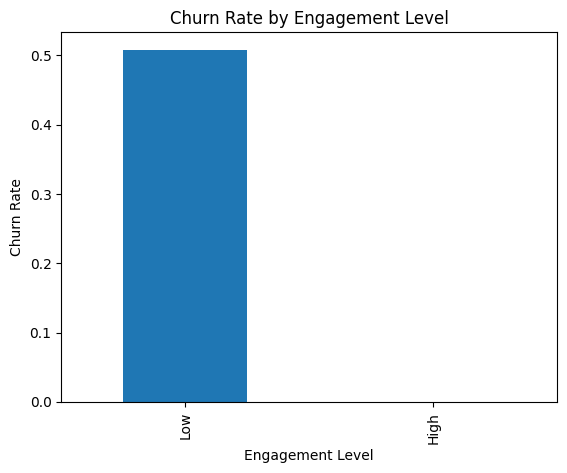

In [121]:
import matplotlib.pyplot as plt

churn_by_engagement = df.groupby("engagement_level")["churned"].mean()

plt.figure()
churn_by_engagement.plot(kind="bar")
plt.title("Churn Rate by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Churn Rate")
plt.show()

Low engagement users show over 50 percent churn.

High engagement users almost never churn.

**Engagement is a strong churn predictor.**

# **Strategic CRM – Churn scoring and action**

In [101]:
y = df["churned"]

In [102]:
X_model = df[[
    "age",
    "watch_hours",
    "avg_watch_time_per_day",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles"
]]

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.3, random_state=42
)

In [104]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [105]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8886666666666667
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       753
           1       0.87      0.91      0.89       747

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



In [106]:
df["churn_score"] = model.predict_proba(X_model)[:,1]
df[["customer_id", "churn_score"]].head()

,customer_id,churn_score
0,a9b75100-82a8-427a-a208-72f24052884a,0.711014
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,0.639955
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,0.003103
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,0.325962
4,4e265c34-103a-4dbb-9553-76c9aa47e946,0.811552


In [107]:
df["risk_level"] = pd.cut(
    df["churn_score"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

df[["customer_id", "segment", "risk_level"]].head()

,customer_id,segment,risk_level
0,a9b75100-82a8-427a-a208-72f24052884a,1,High
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,2,High
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,1,Low
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,2,Medium
4,4e265c34-103a-4dbb-9553-76c9aa47e946,1,High


In [108]:
overall_churn = df["churned"].mean()
overall_retention = 1 - overall_churn
avg_revenue = df["monthly_fee"].mean()

print("Overall churn rate:", round(overall_churn,3))
print("Overall retention rate:", round(overall_retention,3))
print("Average monthly revenue per user:", round(avg_revenue,2))

Overall churn rate: 0.503
Overall retention rate: 0.497
Average monthly revenue per user: 13.68


In [109]:
pd.crosstab(df["segment"], df["risk_level"])

risk_level,Low,Medium,High
segment,,,
0,336,112,771
1,381,122,785
2,668,175,161
3,65,0,0
4,415,1,0
5,202,129,677


In [110]:
kpi_by_segment = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    churn_rate=("churned", "mean"),
    arpu=("monthly_fee", "mean"),
    avg_watch_hours=("watch_hours", "mean"),
    avg_watch_time_day=("avg_watch_time_per_day", "mean"),
    avg_churn_score=("churn_score", "mean")
).round(3)

kpi_by_segment

,customers,churn_rate,arpu,avg_watch_hours,avg_watch_time_day,avg_churn_score
segment,,,,,,
0,1219,0.664,8.990,8.539,0.514,0.639
1,1288,0.616,14.196,9.236,0.562,0.623
2,1004,0.214,16.213,7.707,0.852,0.245
3,65,0.000,14.082,27.604,17.364,0.000
4,416,0.007,13.632,40.408,2.009,0.006
5,1008,0.688,16.180,9.525,0.203,0.684


In [111]:
import numpy as np
import pandas as pd

In [112]:
df["risk_level"] = pd.cut(
    df["churn_score"],
    bins=[0, 0.3, 0.6, 1.0000001],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [113]:
df["monthly_fee"] = pd.to_numeric(df["monthly_fee"], errors="coerce")

df["value_level"] = pd.cut(
    df["monthly_fee"],
    bins=[0, 12, 15, 100],
    labels=["Low", "Mid", "High"],
    include_lowest=True
)

In [114]:
conditions = [
    (df["risk_level"] == "High") & (df["value_level"].isin(["Mid", "High"])),
    (df["risk_level"] == "High") & (df["value_level"] == "Low"),
    (df["risk_level"] == "Low") & (df["value_level"] == "High")
]

choices = [
    "Priority 1 Retention",
    "Low-cost Retention",
    "Upsell"
]

df["action_priority"] = np.select(conditions, choices, default="Monitor")

df["action_priority"].value_counts()

,count
action_priority,
Monitor,1764
Priority 1 Retention,1414
Low-cost Retention,980
Upsell,842


**CRM Marketing Strategy**

*Priority 1 Retention*
- Immediate retention campaign

- Targeted discount

- Personalized email

*Low-cost Retention*

- Reminder email

- Push notification

*Upsell*

- Premium upgrade offer

- Bundle plan

*Monitor*

- Regular communication

- No aggressive incentive

**KPI Targets**

*Inactive High Risk*

- Reduce churn from 68% to 50% within 6 months

*High Risk Segments*

- Reduce churn by 10%

*Top Loyal*

- Increase ARPU by 10%

*Overall Objective*

- Improve retention rate by 5%

- Increase average CLV by 8%